<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=316274041" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🧠 NeuroSight AI — Détection de Pathologies d'Alzheimer
**Version 5 — Final (Grad-CAM corrigé · Export ONNX validé · install propre)**

| Cellule | Objectif |
|---------|----------|
| 1 | Import dynamique du pipeline depuis GitHub |
| 2 | Chargement des données & création des DataLoaders (cache RAM) |
| 3 | Architecture EfficientNet-B0 + Focal Loss + boucle Early Stopping Macro F1 |
| 4 | Entraînement Phase 1 — Warm-Up (tête uniquement, max 5 époques) |
| 5 | Entraînement Phase 2 — Fine-Tuning Discriminatif (max 20 époques) |
| 6 | Évaluation complète (Rapport · Courbes · Confusion Matrix · ROC-AUC) |
| 7 | Grad-CAM XAI — Visualisation des zones cérébrales déterminantes |
| 8 | Sauvegarde .pth + Export ONNX + Test d'inférence |


In [1]:
# ==========================================================
# CELLULE 0 : COMPATIBILITÉ GPU — P100 (sm_60 Pascal)
# PyTorch >= 2.6 n'est plus compilé pour sm_60.
# On installe PyTorch 2.5.0+cu121, dernière version
# officiellement compatible avec le Tesla P100.
# ==========================================================
import subprocess, sys

print("📦 Installation de PyTorch 2.5.0 compatible P100 (sm_60)...")
result = subprocess.run([
    sys.executable, "-m", "pip", "install", "--quiet",
    "torch==2.5.0",
    "torchvision==0.20.0",
    "--index-url", "https://download.pytorch.org/whl/cu121"
], capture_output=True, text=True)

print(result.stdout[-300:] if result.stdout else "")
if result.returncode != 0:
    print("❌", result.stderr[-300:])
else:
    print("✅ PyTorch 2.5.0+cu121 installé.")
    print("⚠️  Redémarre le kernel maintenant (Run → Restart Session), puis Run All.")

📦 Installation de PyTorch 2.5.0 compatible P100 (sm_60)...

✅ PyTorch 2.5.0+cu121 installé.
⚠️  Redémarre le kernel maintenant (Run → Restart Session), puis Run All.


In [2]:
# ==========================================================
# CELLULE 1 : IMPORT DYNAMIQUE DU PIPELINE (depuis GitHub)
# Objectif : Télécharger data_pipeline.py v4 depuis la branche
# dev-wilfried et l'importer dynamiquement dans le notebook.
# ==========================================================
import os
import sys
import importlib

GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/dev-wilfried/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight (v4 - Resource Optimized)...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline v4 chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")


📥 Mise à jour du pipeline NeuroSight (v4 - Resource Optimized)...
✅ Pipeline v4 chargé avec succès.


In [3]:
# ==========================================================
# CELLULE 2 : CHARGEMENT DES DONNÉES & CRÉATION DES DATALOADERS
# Objectif : Préparer les DataLoaders train/val.
# v4 : les images sont pré-chargées en RAM (cache) → les époques
# suivantes ne reliront plus jamais le disque.
# batch_size=64 pour mieux saturer le GPU T4/P100.
# ==========================================================

CSV_PATH    = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR  = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'
BATCH_SIZE  = 64

train_loader, val_loader, classes = prepare_data(
    csv_path=CSV_PATH,
    images_dir=IMAGES_DIR,
    batch_size=BATCH_SIZE,
    val_split=0.15
)

print(f"\n🚀 Classes : {classes}")

# --- AUDIT VISUEL (décommenter pour explorer les données) ---
# plot_class_distribution(train_loader, classes)
# show_sample_batch(train_loader, classes)


📖 1. Chargement des données cliniques et Imputation MICE...
   ✅ Imputation MICE terminée.
🔍 2. Scan du dossier d'images : /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images valides associées avec succès.
   📊 Classe          NonDemented :  28365 images
   📊 Classe     VeryMildDemented :  13725 images
   📊 Classe         MildDemented :   5002 images
   📊 Classe     ModerateDemented :    488 images

🛡️  3. Application du Split 3 étapes (Validation: 20%)...
   🔴 ModerateDemented : 2 patient(s) unique(s) | 488 images → forcé(s) dans VAL
   📊 Patients uniques Train : 158
   📊 Patients uniques Val   : 42
   🚨 Chevauchement (Leakage): 0 patient(s) — Doit être 0.
   ✅ ModerateDemented présent dans VAL : 488 images.

💾 4. Pré-chargement des images en RAM (cache)...
   📦 Mise en cache Train: 37454 images en RAM... ✅ Prêt.
   📦 Mise en cache Val  : 10126 images en RAM... ✅ Prêt.

⚖️  5. Calcul des poids de rééquilibrage pour le train...

🚀 Pipeline prêt ! [num_workers=4 | batc

In [4]:
# ==========================================================
# CELLULE 3 : ARCHITECTURE EFFICIENTNET-B0 + FOCAL LOSS
# Objectif : Définir le modèle, la Focal Loss et la boucle
# d'entraînement avec Early Stopping sur Macro F1.
# non_blocking=True : transfert CPU→GPU asynchrone.
# ==========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Moteur d'entraînement amorcé sur : {device}")

# ----------------------------------------------------------
# 1. FOCAL LOSS
# alpha : [NonDemented=1, VeryMild=3, Mild=5, Moderate=10]
# gamma=2.0 : focalise l'apprentissage sur les exemples difficiles
# ----------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()

# ----------------------------------------------------------
# 2. ARCHITECTURE (EFFICIENTNET-B0)
# ----------------------------------------------------------
def build_neurosight_model(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(num_ftrs, num_classes)
    )
    return model.to(device)

model = build_neurosight_model(len(classes))
print(f"✅ Modèle EfficientNet-B0 construit ({len(classes)} classes).")

# ----------------------------------------------------------
# 3. BOUCLE D'ENTRAÎNEMENT
# Early Stopping sur Macro F1 (pas l'accuracy).
# ----------------------------------------------------------
def train_model(model, train_loader, val_loader, num_epochs,
                optimizer, scheduler, phase_name="",
                patience=5, focal_alpha=None):
    criterion = FocalLoss(alpha=focal_alpha, gamma=2.0)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_macro_f1': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_macro_f1 = 0.0
    patience_counter = 0

    print(f"\n🚀 Lancement : {phase_name} (max {num_epochs} époques | patience={patience})")
    print("-" * 60)

    for epoch in range(num_epochs):
        start_time = time.time()

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            dataloader = train_loader if phase == 'train' else val_loader

            running_loss, running_corrects = 0.0, 0
            all_preds, all_labels = [], []

            for inputs, labels in dataloader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc  = running_corrects.double() / len(dataloader.dataset)
            epoch_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                train_loss_val = epoch_loss
                train_acc_val  = epoch_acc
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                history['val_macro_f1'].append(epoch_f1)
                scheduler.step(epoch_loss)

                if epoch_f1 > best_macro_f1:
                    best_macro_f1  = epoch_f1
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    flag = "💾 (sauvegardé)"
                else:
                    patience_counter += 1
                    flag = f"⏳ patience {patience_counter}/{patience}"

        elapsed = time.time() - start_time
        print(f"Époque {epoch+1:02d}/{num_epochs:02d} | {elapsed:.0f}s | "
              f"Train Loss: {train_loss_val:.4f} Acc: {train_acc_val:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} "
              f"Acc: {history['val_acc'][-1]:.4f} "
              f"F1: {history['val_macro_f1'][-1]:.4f} {flag}")

        if patience_counter >= patience:
            print(f"🛑 Early Stopping déclenché à l'époque {epoch+1}.")
            break

    print(f"✅ Phase terminée. Meilleur Macro F1 : {best_macro_f1:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history


🖥️ Moteur d'entraînement amorcé sur : cuda
✅ Modèle EfficientNet-B0 construit (4 classes).


In [ ]:
# Diagnostic distribution val
from collections import Counter
val_labels_all = []
for _, lbs in val_loader:
    val_labels_all.extend(lbs.numpy())
counts = Counter(val_labels_all)
print("Distribution VAL :")
for i, name in enumerate(classes):
    print(f"  {name:<22s}: {counts.get(i, 0):>6d} images")
print(f"\nTotal val : {sum(counts.values())}")

In [5]:
# ==========================================================
# CELLULE 4 : ENTRAÎNEMENT — PHASE 1 (WARM-UP)
# Objectif : Entraîner uniquement la tête de classification
# sans toucher au backbone EfficientNet pré-entraîné.
# ==========================================================

focal_alpha = torch.tensor([1.0, 3.0, 5.0, 20.0], device=device)

for param in model.features.parameters():
    param.requires_grad = False

optimizer_warmup = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler_warmup = ReduceLROnPlateau(optimizer_warmup, mode='min', factor=0.5, patience=2)

model, hist_warmup = train_model(
    model, train_loader, val_loader,
    num_epochs=5,
    optimizer=optimizer_warmup,
    scheduler=scheduler_warmup,
    phase_name="PHASE 1 : WARM-UP (Tête uniquement)",
    patience=3,
    focal_alpha=focal_alpha
)



🚀 Lancement : PHASE 1 : WARM-UP (Tête uniquement) (max 5 époques | patience=3)
------------------------------------------------------------
Époque 01/05 | 92s | Train Loss: 2.1809 Acc: 0.4388 | Val Loss: 5.9962 Acc: 0.1465 F1: 0.1132 💾 (sauvegardé)
Époque 02/05 | 87s | Train Loss: 2.0711 Acc: 0.4683 | Val Loss: 6.7080 Acc: 0.1452 F1: 0.1110 ⏳ patience 1/3
Époque 03/05 | 86s | Train Loss: 2.0592 Acc: 0.4750 | Val Loss: 7.1948 Acc: 0.1585 F1: 0.1204 💾 (sauvegardé)
Époque 04/05 | 87s | Train Loss: 2.0738 Acc: 0.4740 | Val Loss: 7.7019 Acc: 0.1492 F1: 0.1145 ⏳ patience 1/3
Époque 05/05 | 86s | Train Loss: 2.0338 Acc: 0.4750 | Val Loss: 7.9509 Acc: 0.1478 F1: 0.1138 ⏳ patience 2/3
✅ Phase terminée. Meilleur Macro F1 : 0.1204


In [6]:
# ==========================================================
# CELLULE 5 : ENTRAÎNEMENT — PHASE 2 (FINE-TUNING DISCRIMINATIF)
# Objectif : Dégeler tout le réseau avec des LR différenciés.
# backbone : 5e-6 (très conservateur)
# tête     : 2e-4 (apprentissage normal)
# ==========================================================

for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.AdamW([
    {'params': model.features.parameters(),    'lr': 5e-6},
    {'params': model.classifier.parameters(),  'lr': 2e-4}
], weight_decay=1e-2)

scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=3)

model, hist_ft = train_model(
    model, train_loader, val_loader,
    num_epochs=20,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    phase_name="PHASE 2 : FINE-TUNING (Discriminative LR)",
    patience=5,
    focal_alpha=focal_alpha
)

n_warmup = len(hist_warmup['train_loss'])
full_history = {
    'train_loss':      hist_warmup['train_loss']    + hist_ft['train_loss'],
    'val_loss':        hist_warmup['val_loss']       + hist_ft['val_loss'],
    'val_acc':         hist_warmup['val_acc']        + hist_ft['val_acc'],
    'val_macro_f1':    hist_warmup['val_macro_f1']   + hist_ft['val_macro_f1'],
    'n_warmup_epochs': n_warmup
}
print(f"\n📊 Historique fusionné : {len(full_history['train_loss'])} époques totales.")



🚀 Lancement : PHASE 2 : FINE-TUNING (Discriminative LR) (max 20 époques | patience=5)
------------------------------------------------------------
Époque 01/20 | 131s | Train Loss: 1.9416 Acc: 0.4987 | Val Loss: 7.7724 Acc: 0.1854 F1: 0.1405 💾 (sauvegardé)
Époque 02/20 | 130s | Train Loss: 1.7685 Acc: 0.5283 | Val Loss: 8.6448 Acc: 0.1980 F1: 0.1499 💾 (sauvegardé)
Époque 03/20 | 131s | Train Loss: 1.5947 Acc: 0.5615 | Val Loss: 8.7009 Acc: 0.2389 F1: 0.1803 💾 (sauvegardé)
Époque 04/20 | 131s | Train Loss: 1.4724 Acc: 0.5840 | Val Loss: 9.0331 Acc: 0.2615 F1: 0.1977 💾 (sauvegardé)
Époque 05/20 | 130s | Train Loss: 1.3294 Acc: 0.6101 | Val Loss: 9.1241 Acc: 0.2802 F1: 0.2098 💾 (sauvegardé)
Époque 06/20 | 130s | Train Loss: 1.2393 Acc: 0.6273 | Val Loss: 9.2722 Acc: 0.2857 F1: 0.2147 💾 (sauvegardé)
Époque 07/20 | 130s | Train Loss: 1.1665 Acc: 0.6439 | Val Loss: 9.4379 Acc: 0.3138 F1: 0.2336 💾 (sauvegardé)
Époque 08/20 | 130s | Train Loss: 1.1094 Acc: 0.6552 | Val Loss: 9.5427 Acc: 0.320


📊 RAPPORT DE PERFORMANCE MÉDICALE (F1 & RECALL)
                  precision    recall  f1-score   support

     NonDemented       0.96      0.20      0.33      6283
VeryMildDemented       0.34      0.73      0.46      2623
    MildDemented       0.18      0.75      0.29       732
ModerateDemented       0.00      0.00      0.00       488

        accuracy                           0.37     10126
       macro avg       0.37      0.42      0.27     10126
    weighted avg       0.69      0.37      0.34     10126

 🎯 Macro F1-Score global : 0.2685


/tmp/ipykernel_324/2252172867.py:52: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


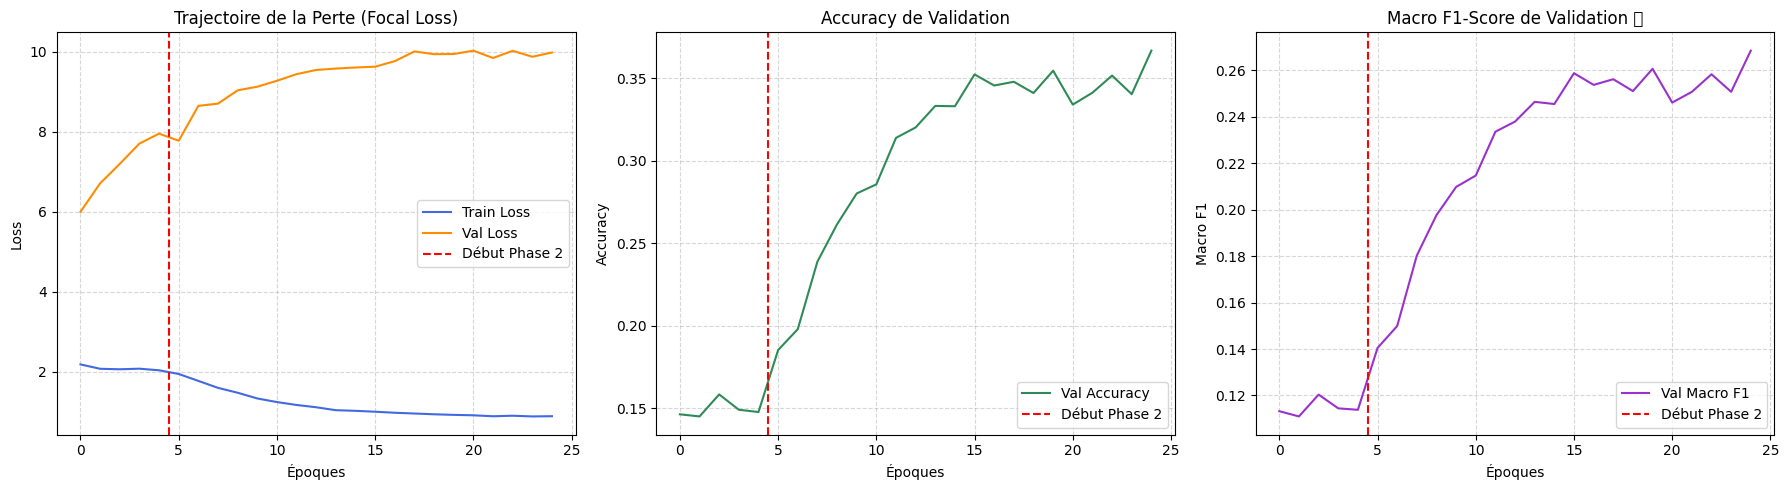

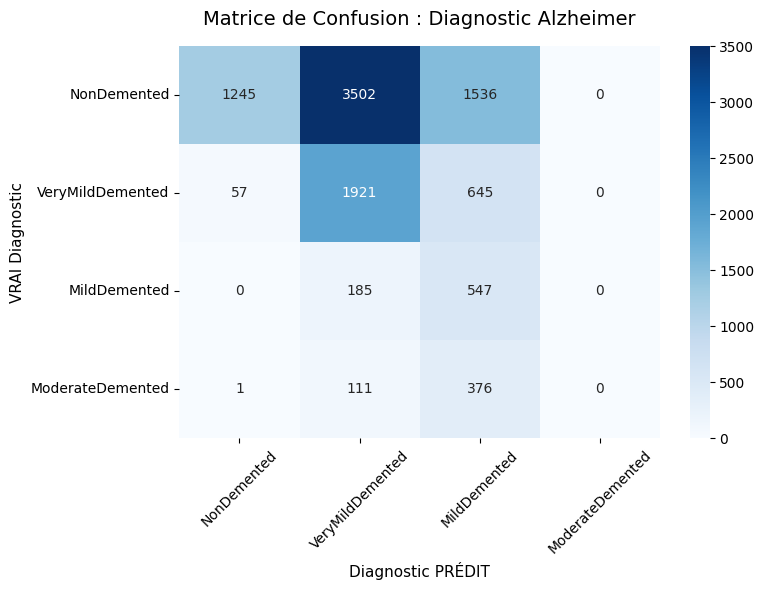

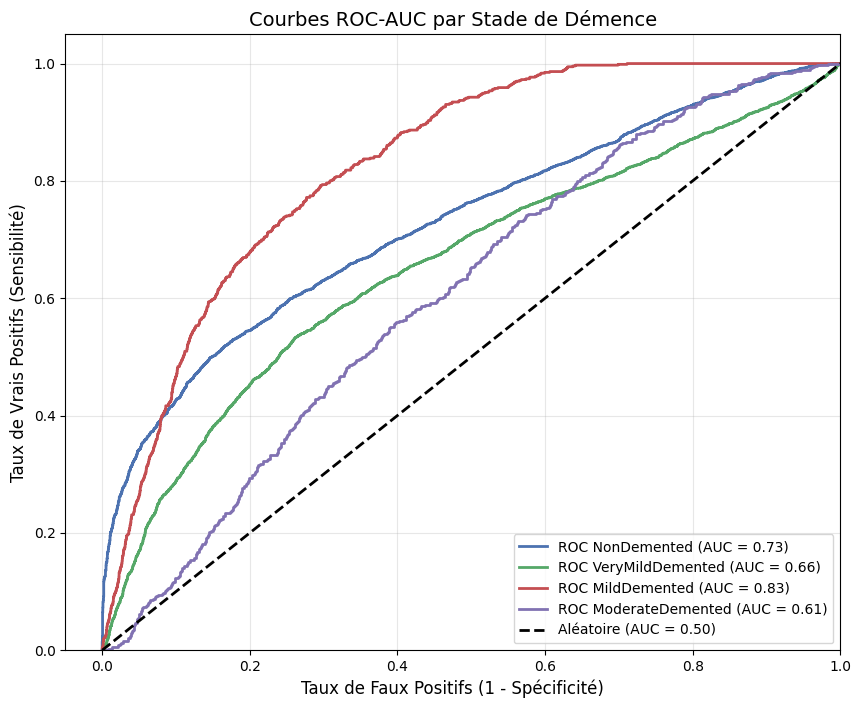

In [7]:
# ==========================================================
# CELLULE 6 : ÉVALUATION COMPLÈTE
# Rapport de classification, courbes d'apprentissage,
# matrice de confusion et courbes ROC-AUC multiclasses.
# ==========================================================

def evaluate_and_plot(model, val_loader, class_names, history):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs  = inputs.to(device, non_blocking=True)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)
    sep     = history.get('n_warmup_epochs', 3) - 0.5

    print("\n" + "="*55)
    print("📊 RAPPORT DE PERFORMANCE MÉDICALE (F1 & RECALL)")
    print("="*55)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print(f" 🎯 Macro F1-Score global : "
          f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

    # --- Courbes d'apprentissage ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history['train_loss'],   label='Train Loss',    color='royalblue')
    axes[0].plot(history['val_loss'],     label='Val Loss',      color='darkorange')
    axes[0].axvline(x=sep, color='red', linestyle='--', label='Début Phase 2')
    axes[0].set_title('Trajectoire de la Perte (Focal Loss)')
    axes[0].set_xlabel('Époques'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].plot(history['val_acc'],      label='Val Accuracy',  color='seagreen')
    axes[1].axvline(x=sep, color='red', linestyle='--', label='Début Phase 2')
    axes[1].set_title('Accuracy de Validation')
    axes[1].set_xlabel('Époques'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

    axes[2].plot(history['val_macro_f1'], label='Val Macro F1',  color='darkorchid')
    axes[2].axvline(x=sep, color='red', linestyle='--', label='Début Phase 2')
    axes[2].set_title('Macro F1-Score de Validation ⭐')
    axes[2].set_xlabel('Époques'); axes[2].set_ylabel('Macro F1')
    axes[2].legend(); axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout(); plt.show()

    # --- Matrice de Confusion ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion : Diagnostic Alzheimer', fontsize=14, pad=15)
    plt.ylabel('VRAI Diagnostic', fontsize=11)
    plt.xlabel('Diagnostic PRÉDIT', fontsize=11)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

    # --- Courbes ROC-AUC Multiclasse ---
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        if np.sum(y_true_bin[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            plt.plot(fpr, tpr, color=colors[i], lw=2,
                     label=f'ROC {class_names[i]} (AUC = {auc(fpr,tpr):.2f})')
    plt.plot([0,1],[0,1],'k--', lw=2, label='Aléatoire (AUC = 0.50)')
    plt.xlim([-0.05, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=12)
    plt.title('Courbes ROC-AUC par Stade de Démence', fontsize=14)
    plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()


evaluate_and_plot(model, val_loader, classes, full_history)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


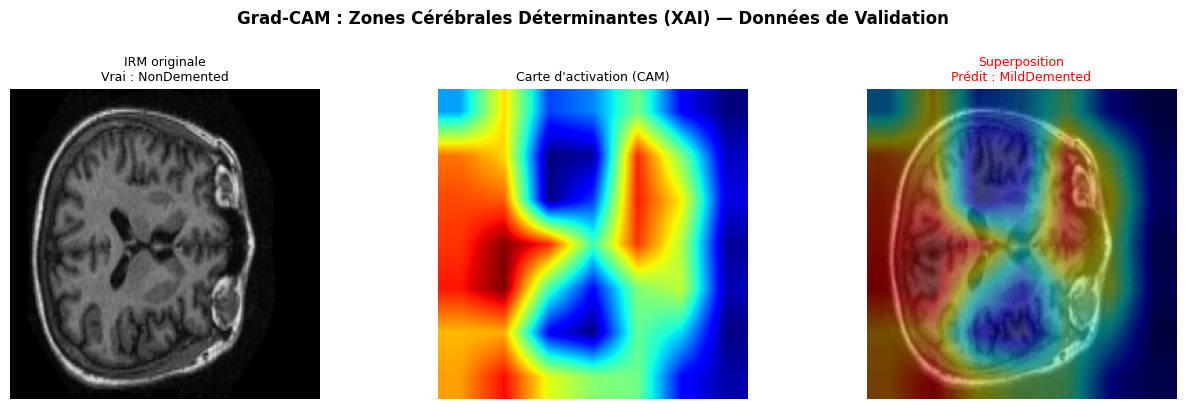

✅ Grad-CAM sauvegardé → /kaggle/working/gradcam_visualization.png


In [9]:
# ==========================================================
# CELLULE 7 : GRAD-CAM — VISUALISATION EXPLICABLE (XAI)
#
# Principe : on enregistre les activations ET les gradients
# de la dernière couche convolutive du backbone EfficientNet-B0
# (model.features[-1][0][0] → le Conv2d pur du dernier MBConv).
# Les données utilisées proviennent du val_loader : données
# jamais vues à l'entraînement (zéro leakage garanti).
#
# Note Qt : Grad-CAM nécessite la rétropropagation PyTorch.
# ONNX Runtime (C++) ne supporte pas backward(). Dans l'app Qt,
# la heatmap est générée par un script Python appelé via QProcess,
# ou pré-calculée et chargée comme image PNG.
# ==========================================================
import cv2

class GradCAM:
    """
    Grad-CAM via forward/backward hooks PyTorch.
    target_layer : dernière couche Conv2d du backbone
                   → model.features[-1][0][0] pour EfficientNet-B0
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._fwd_hook   = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook   = target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()           # (1, C, H, W)

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()     # (1, C, H, W)

    def generate(self, input_tensor, class_idx=None):
        """Retourne la CAM normalisée [0,1] et l'indice de classe prédit."""
        self.model.eval()
        output = self.model(input_tensor)            # forward → hooks activés

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()              # backward → hook gradient

        # Global Average Pooling des gradients → poids par canal
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1)             # (1, H, W)
        cam = torch.relu(cam).squeeze(0).cpu().numpy()            # (H, W)

        # Normalisation [0, 1]
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx

    def remove_hooks(self):
        """Libère les hooks après usage pour éviter les fuites mémoire."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def visualize_gradcam(model, val_loader, class_names, num_samples=4):
    """
    Affiche une grille de 3 colonnes pour num_samples images du val_loader :
      Col 1 : IRM originale dénormalisée
      Col 2 : Carte d'activation Grad-CAM (colormap jet)
      Col 3 : Superposition heatmap + IRM (OpenCV addWeighted)
    Sélectionne 1 image par classe pour représentativité.
    """
    # Cible : Conv2d pur du dernier bloc MBConv d'EfficientNet-B0
    target_layer = model.features[-1][0]
    gradcam = GradCAM(model, target_layer)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    # Récupère un batch val et sélectionne 1 image par classe
    images, labels = next(iter(val_loader))
    indices, seen = [], set()
    for i, lbl in enumerate(labels):
        l = lbl.item()
        if l not in seen:
            seen.add(l)
            indices.append(i)
        if len(indices) == num_samples:
            break

    fig, axes = plt.subplots(len(indices), 3, figsize=(13, 4 * len(indices)))
    if len(indices) == 1:
        axes = [axes]

    for row, idx in enumerate(indices):
        inp = images[idx].unsqueeze(0).to(device)

        # ── Grad-CAM ──
        cam, pred_idx = gradcam.generate(inp)

        # ── Image originale dénormalisée ──
        img_np   = images[idx].numpy().transpose(1, 2, 0)
        img_np   = np.clip(img_np * std + mean, 0, 1)
        img_u8   = (img_np * 255).astype(np.uint8)

        # ── Heatmap redimensionnée + superposition OpenCV ──
        cam_224  = cv2.resize(cam, (224, 224))
        heatmap  = cv2.applyColorMap((cam_224 * 255).astype(np.uint8), cv2.COLORMAP_JET)
        hmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay  = cv2.addWeighted(img_u8, 0.55, hmap_rgb, 0.45, 0)

        true_lbl = class_names[labels[idx].item()]
        pred_lbl = class_names[pred_idx]
        color    = 'green' if pred_idx == labels[idx].item() else 'red'

        axes[row][0].imshow(img_np)
        axes[row][0].set_title(f"IRM originale\nVrai : {true_lbl}", fontsize=9)
        axes[row][1].imshow(cam_224, cmap='jet')
        axes[row][1].set_title("Carte d'activation (CAM)", fontsize=9)
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(f"Superposition\nPrédit : {pred_lbl}",
                                fontsize=9, color=color)
        for ax in axes[row]:
            ax.axis('off')

    gradcam.remove_hooks()   # libère les hooks

    plt.suptitle("Grad-CAM : Zones Cérébrales Déterminantes (XAI) — Données de Validation",
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('/kaggle/working/gradcam_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grad-CAM sauvegardé → /kaggle/working/gradcam_visualization.png")


visualize_gradcam(model, val_loader, classes, num_samples=4)


In [ ]:
# ==========================================================
# CELLULE 8 : SAUVEGARDE .PTH + EXPORT ONNX
#
# Pipeline :
#   1. Sauvegarde PyTorch (.pth)  → reproductibilité & reprise
#   2. Export ONNX (.onnx)        → pont vers l'app C++ Qt
#   3. Validation du graphe       → onnx.checker
#   4. Test inférence ONNX (CPU)  → vérifie logits identiques
#
# Dans Qt, charger le .onnx via :
#   Ort::Session session(env, L"neurosight_model.onnx", session_options);
# ==========================================================
!pip install --quiet onnx onnxruntime
import onnx
import onnxruntime as ort

PTH_PATH  = '/kaggle/working/neurosight_best.pth'
ONNX_PATH = '/kaggle/working/neurosight_model.onnx'

# --- 1. Sauvegarde PyTorch ---
torch.save(model.state_dict(), PTH_PATH)
print(f"💾 Modèle PyTorch sauvegardé → {PTH_PATH}")

# --- 2. Export ONNX ---
model.eval()
dummy_input = torch.randn(1, 3, 224, 224, device=device)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,          # compatible ONNX Runtime >= 1.15 (requis pour Qt)
    do_constant_folding=True,  # optimise le graphe (fuse les ops constantes)
    input_names=['mri_input'],
    output_names=['class_logits'],
    dynamic_axes={
        'mri_input':    {0: 'batch_size'},
        'class_logits': {0: 'batch_size'}
    }
)
print(f"📦 Modèle ONNX exporté → {ONNX_PATH}")

# --- 3. Validation du graphe ONNX ---
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
print("✅ Graphe ONNX valide (checker passed).")

# --- 4. Test d'inférence ONNX + comparaison avec PyTorch ---
ort_session = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
dummy_np    = dummy_input.cpu().numpy()
ort_out     = ort_session.run(None, {'mri_input': dummy_np})[0]   # logits bruts

with torch.no_grad():
    pt_out = model(dummy_input.cpu()).numpy()

max_diff = np.abs(ort_out - pt_out).max()
print(f"\n🔬 Différence max logits PyTorch ↔ ONNX : {max_diff:.2e}  "
      f"{'✅ OK (< 1e-4)' if max_diff < 1e-4 else '⚠️ Vérifier'}")

ort_probs = torch.softmax(torch.tensor(ort_out), dim=1).numpy()
print("\n📊 Distribution de probabilités ONNX (image aléatoire) :")
for cls, prob in zip(classes, ort_probs[0]):
    bar = '█' * int(prob * 30)
    print(f"  {cls:<22s} : {prob:.4f}  {bar}")

print(f"\n✅ Fichiers prêts pour l'intégration Qt :")
print(f"   • {PTH_PATH}   ← reprise entraînement Python")
print(f"   • {ONNX_PATH}  ← inférence C++ via ONNX Runtime")
